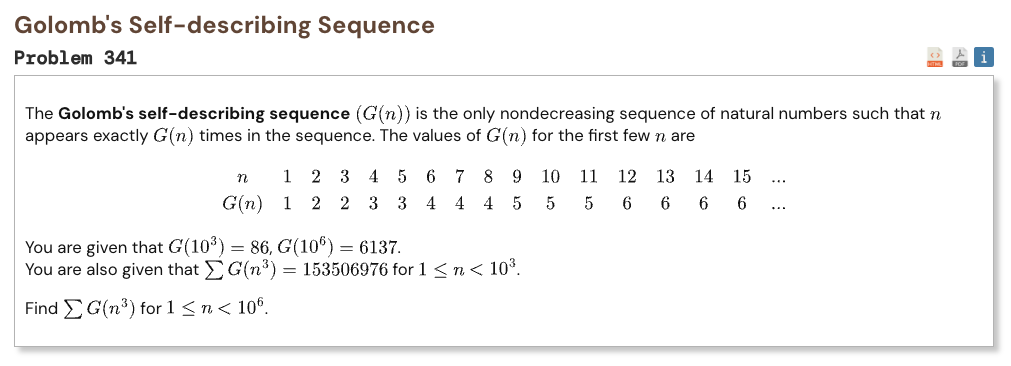

## Initial approach

* store the Golomb sequence only up to the point needed for lookup
* also store where each repeated-value block ends
* also store the cumulative weighted block sums
* for a query like G(n^3), find the block containing that index
* compute the exact position inside that block with integer division
* this avoids generating the sequence up to 10^18
* the small given checks confirm the method

In [1]:
def lower_bound(arr, value):
    lo = 0
    hi = len(arr)

    while lo < hi:
        mid = (lo + hi) // 2

        if arr[mid] < value:
            lo = mid + 1
        else:
            hi = mid

    return lo

def build_tables(target):
    g = [0, 1]
    ends = [0, 1]
    weighted = [0, 1]

    n = 2

    while weighted[-1] < target:
        value = 1 + g[n - g[g[n - 1]]]
        g.append(value)
        ends.append(ends[-1] + value)
        weighted.append(weighted[-1] + n * value)
        n += 1

    return ends, weighted

def golomb_query(x, ends, weighted):
    block = lower_bound(weighted, x)

    previous_weighted = weighted[block - 1]
    previous_end = ends[block - 1]

    offset = (x - previous_weighted + block - 1) // block

    return previous_end + offset

def solve(limit):
    ends, weighted = build_tables(limit ** 3)

    total = 0

    for n in range(1, limit):
        total += golomb_query(n ** 3, ends, weighted)

    return total

ends, weighted = build_tables(10 ** 18)

assert golomb_query(10 ** 3, ends, weighted) == 86
assert golomb_query(10 ** 6, ends, weighted) == 6137
assert solve(1000) == 153506976

In [2]:
%%time
result = solve(10 ** 6)
print("Result:", result)

Result: 56098610614277014
CPU times: user 3.19 s, sys: 379 ms, total: 3.57 s
Wall time: 3.83 s
